# PatchTST SSL — NinaPro DB7 Exercise B
### Data pipeline from · 90/10 split · Data-leakage-free (split-before-windowing)

| Change | Source |
|---|---|
| Data loading: `EMGAccPreprocessor` + `SubjectLoader` (loads raw `.mat` files) |
| Windowing: 200 ms window / **100 ms stride** (50 % overlap) |
| Paths: `_find_kaggle_input()` + per-subject `.npz` checkpoint |
| **SPLIT BEFORE WINDOWING** — raw signal split per-subject first, windows built from each split | **Leakage fix** |
| Scaler fit **only on train windows** (no leakage) | Fixed |
| Normalisation: **per-channel z-score fit on train split only** | Fixed |
| Epochs: SSL 100–150 min/max, Fine-tune 100–150 min/max | Updated |
| All PatchTST architecture fixes from v2 | Previous fix |

---
## Why split-before-windowing eliminates data leakage

The original notebook split on **window indices** after building windows from the full
signal. Because the window stride (200 samples) < window length (400 samples), consecutive
windows share 200 samples. When the split boundary falls between two overlapping windows,
one of those windows lands in train and the other in test — but they share raw signal samples.
That is a **boundary leakage** of up to 200 samples per subject per split point.

The fix applied here:
1. **Split the raw signal arrays** (per-subject) at the 90/10 sample boundary — no window
 is ever built that straddles this cut.
2. **Window each split separately** — train windows only see train samples; test windows
 only see test samples.
3. **Scaler fitted on train windows only** — val/test normalised with train statistics.

Mixed precision (`torch.amp`) and quantization only change numerical storage (float16/int8)
and cannot remove signal that has already been included in a batch.


## §0 Installs & imports

In [1]:
import subprocess, sys
for pkg in ['einops', 'timm', 'umap-learn', 'thop']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

%matplotlib inline
import os, gc, time, json, warnings, math, random
from pathlib import Path
from math import gcd
from typing import Optional, Tuple, List

import numpy as np
import pandas as pd
from scipy import io
from scipy.signal import resample_poly
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

# torch.amp (not deprecated torch.cuda.amp)
from torch.amp import GradScaler, autocast

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve, silhouette_score,
)
from sklearn.preprocessing import label_binarize

try:
    import umap as umap_module
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False

try:
    from thop import profile as thop_profile
    HAS_THOP = True
except ImportError:
    HAS_THOP = False

warnings.filterwarnings('ignore')
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except OSError:
    try:
        plt.style.use('seaborn-darkgrid')
    except OSError:
        pass
sns.set_palette('husl')
print('Imports OK')


2026-04-02 16:33:44.681429: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775147624.906444      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775147624.973528      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775147625.492152      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775147625.492195      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775147625.492198      24 computation_placer.cc:177] computation placer alr

Imports OK


## §1 Configuration
Paths, windowing parameters, and split ratio.


In [2]:
# ── Path discovery ──────────────────────────────────────────
def _find_kaggle_input() -> Path:
    """
    Walks /kaggle/input searching for a directory that contains Subject_XX
    sub-directories. Falls back to a sensible default if not found.
    Taken verbatim from the notebook.
    """
    base = Path('/kaggle/input')
    if not base.exists():
        return Path('/kaggle/input/datasets/rayaanraza1/ninapro-db7')

    def _has_subjects(p):
        return p.is_dir() and any(
            c.is_dir() and c.name.lower().startswith('subject_')
            for c in p.iterdir())

    def _search(root, depth=0):
        if depth > 5: return None
        if _has_subjects(root): return root
        try:
            for child in sorted(root.iterdir()):
                if child.is_dir():
                    r = _search(child, depth + 1)
                    if r is not None: return r
        except PermissionError:
            pass
        return None

    r = _search(base)
    return r if r else Path('/kaggle/input/datasets/rayaanraza1/ninapro-db7')


class CFG:
    # ── Paths ───────────────────────────────────────
    KAGGLE_INPUT = _find_kaggle_input()
    KAGGLE_WORKING = Path('/kaggle/working')
    CKPT_DIR = KAGGLE_WORKING / 'ckpts_patchtst_ssl'
    DATA_CACHE_DIR = KAGGLE_WORKING / 'cache_patchtst'
    PLOT_DIR = KAGGLE_WORKING / 'plots_patchtst_ssl'
    RESULTS_DIR = KAGGLE_WORKING / 'results_patchtst_ssl'

    # ── Dataset ───────────────────────────────────────────────
    SUBJECTS = list(range(1, 23))
    EMG_FS = 2000
    ACC_FS = 148
    TARGET_FS = 2000
    EMG_KEY = 'emg'
    ACC_KEY = 'acc'
    LBL_KEY = 'restimulus'
    GESTURE_MIN = 13
    GESTURE_MAX = 29
    N_CLASSES = GESTURE_MAX - GESTURE_MIN + 1  # 17
    EMG_CHANNELS = 12
    ACC_CHANNELS = 36
    N_CHANNELS = EMG_CHANNELS + ACC_CHANNELS  # 48

    # ── Windowing ───────────────
    WIN_MS = 200
    STEP_MS = 200
    WIN_SAMPLES = int(WIN_MS * TARGET_FS / 1000)   # 400
    STEP_SAMPLES = int(STEP_MS * TARGET_FS / 1000)  # 400

    # ── Split ─────────────────────────────────────────────────
    TEST_FRAC = 0.10
    VAL_FRAC_OF_TRAIN = 0.10

    # ── PatchTST architecture ─────────────────────────────────────────────
    PATCH_LEN = 20
    PATCH_STRIDE = 20
    NUM_PATCH = (max(WIN_SAMPLES, PATCH_LEN) - PATCH_LEN) // PATCH_STRIDE + 1  # 20
    D_MODEL = 128
    N_HEADS = 8
    N_LAYERS = 4
    D_FF = 256
    DROPOUT = 0.1
    ATTN_DROPOUT = 0.0
    HEAD_DROPOUT = 0.0
    NORM = 'BatchNorm'
    RES_ATTENTION = True
    PRE_NORM = False
    SHARED_EMBEDDING = False

    # ── SSL pre-training ──────────────────────────────────────────────────
    MASK_RATIO = 0.4
    AUG_NOISE_STD = 0.05
    AUG_SCALE_LO = 0.8
    AUG_SCALE_HI = 1.2
    AUG_SHIFT_MAX = 10
    AUG_JITTER_PROB = 0.5
    SSL_LR = 1e-3
    SSL_WD = 1e-4
    SSL_EPOCHS = 150      
    SSL_MIN_EPOCHS = 100      
    SSL_PATIENCE = 15
    SSL_BATCH = 256
    SSL_CKPT_EVERY_N = 5
    GRAD_ACCUM = 1

    # ── Downstream ────────────────────────────────────────────────────────
    FT_LR = 5e-4
    FT_WD = 1e-4
    FT_EPOCHS = 150
    FT_MIN_EPOCHS = 100
    FT_PATIENCE = 20
    FT_BATCH = 256
    FT_CKPT_EVERY_N = 5

    # ── Analysis ──────────────────────────────────────────────────────────
    VIZ_SAMPLES = 3000
    KNN_KS = (1, 5, 20)
    LABEL_FRACS = (0.01, 0.05, 0.10, 0.25, 0.50)

    # ── Misc ──────────────────────────────────────────────────────────────
    SEED = 42
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    DEVICE_TYPE = 'cuda' if torch.cuda.is_available() else 'cpu'
    NUM_WORKERS = 2
    USE_AMP = True          # mixed-precision (fp16 forward, fp32 master weights)
    # Data arrays stored as float16 on disk (halves RAM vs float32)
    # Encoder forward runs in fp16 via autocast; gradients kept fp32 by GradScaler


random.seed(CFG.SEED)
np.random.seed(CFG.SEED)
torch.manual_seed(CFG.SEED)
if CFG.DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(CFG.SEED)
    torch.backends.cudnn.benchmark = True

for d in [CFG.CKPT_DIR, CFG.DATA_CACHE_DIR, CFG.PLOT_DIR, CFG.RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = [f'G{i}' for i in range(CFG.GESTURE_MIN, CFG.GESTURE_MAX + 1)]

print(f'Device : {CFG.DEVICE}')
print(f'Data input : {CFG.KAGGLE_INPUT}')
print(f'Window : {CFG.WIN_SAMPLES} samples ({CFG.WIN_MS} ms)')
print(f'Stride : {CFG.STEP_SAMPLES} samples ({CFG.STEP_MS} ms)')
print(f'Split : {int((1-CFG.TEST_FRAC)*100)}/{int(CFG.TEST_FRAC*100)} train/test [90/10]')
print(f'Classes : {CFG.N_CLASSES} ({CFG.GESTURE_MIN}-{CFG.GESTURE_MAX})')
print(f'Channels : {CFG.N_CHANNELS} (EMG={CFG.EMG_CHANNELS} + ACC={CFG.ACC_CHANNELS})')
print(f'Patch len/stride: {CFG.PATCH_LEN}/{CFG.PATCH_STRIDE} -> {CFG.NUM_PATCH} patches')
print(f'Shared embedding: {CFG.SHARED_EMBEDDING} (False = CI mode)')


Device : cuda
Data input : /kaggle/input/datasets/rayaanraza1/ninapro-db7/Dataset
Window : 400 samples (200 ms)
Stride : 400 samples (200 ms)
Split : 90/10 train/test [90/10]
Classes : 17 (13-29)
Channels : 48 (EMG=12 + ACC=36)
Patch len/stride: 20/20 -> 20 patches
Shared embedding: False (False = CI mode)


## §2 Data loading — pipeline

`EMGAccPreprocessor` loads raw `.mat` files and upsamples ACC to EMG rate.
`SubjectLoader` caches per-subject `.npz` files and builds windows.

**Leakage fix**: windows are built *after* the subject data is cached; the
train/test split is applied to the full window pool using stratified sampling,
and the `ChannelNormalizer` is fitted **only on train windows**.


In [3]:
# -- EMGAccPreprocessor -----------------------------------------
class EMGAccPreprocessor:
    """
    Loads EMG + ACC from a .mat file.
    ACC is upsampled to EMG rate when lengths differ.
    Only gesture labels in [GESTURE_MIN, GESTURE_MAX] are kept.
    """
    def _find_key(self, data, candidates):
        for c in candidates:
            for k in data:
                if k.lower() == c.lower():
                    return k
        return None

    def apply(self, mat_path: Path):
        data = io.loadmat(str(mat_path))
        emg_key = self._find_key(data, [CFG.EMG_KEY])
        acc_key = self._find_key(data, [CFG.ACC_KEY, 'glove'])
        lbl_key = self._find_key(data, [CFG.LBL_KEY, 'stimulus', 'label', 'labels'])

        if emg_key is None:
            raise KeyError(f'No EMG key in {mat_path.name}.')
        if lbl_key is None:
            raise KeyError(f'No label key in {mat_path.name}.')

        emg = data[emg_key].astype(np.float32)
        labels = data[lbl_key].flatten().astype(np.int32)

        if acc_key is not None:
            acc = data[acc_key].astype(np.float32)
            if len(acc) != len(emg):
                factor = len(emg) / len(acc)
                up = round(factor * CFG.ACC_FS)
                down = CFG.ACC_FS
                g = gcd(up, down)
                acc = resample_poly(acc, up // g, down // g,
                                    axis=0).astype(np.float32)
            if len(acc) > len(emg):
                acc = acc[:len(emg)]
            elif len(acc) < len(emg):
                pad = np.zeros((len(emg) - len(acc), acc.shape[1]), dtype=np.float32)
                acc = np.vstack([acc, pad])
        else:
            acc = np.zeros((len(emg), 0), dtype=np.float32)

        n = min(len(emg), len(labels))
        emg, acc, labels = emg[:n], acc[:n], labels[:n]

        mask = (labels >= CFG.GESTURE_MIN) & (labels <= CFG.GESTURE_MAX)
        return emg[mask], acc[mask], labels[mask]


# -- SubjectLoader -----------------------------------------------
class SubjectLoader:
    """
    Loads all subjects, caches per-subject .npz files, builds windows.
    """
    def __init__(self):
        self.preprocessor = EMGAccPreprocessor()
        self.cache_dir = CFG.DATA_CACHE_DIR

    def _ckpt_path(self, sid):
        return self.cache_dir / f'subj_{sid:02d}_exB.npz'

    def _find_subject_dir(self, sid):
        candidates = [
            CFG.KAGGLE_INPUT / f'Subject_{sid}',
            CFG.KAGGLE_INPUT / f'subject_{sid}',
            CFG.KAGGLE_INPUT / f'S{sid}',
            CFG.KAGGLE_INPUT / f's{sid}',
        ]
        for p in candidates:
            if p.is_dir(): return p
        for p in sorted(CFG.KAGGLE_INPUT.iterdir()):
            if p.is_dir() and p.name.lower().endswith(str(sid)):
                return p
        raise FileNotFoundError(
            f'Cannot find subject {sid} under {CFG.KAGGLE_INPUT}.')

    def _load_subject(self, sid):
        subj_dir = self._find_subject_dir(sid)
        mat_files = sorted(subj_dir.glob('*.mat')) or sorted(subj_dir.rglob('*.mat'))
        emg_parts, acc_parts, lbl_parts = [], [], []
        for mat_file in mat_files:
            try:
                emg, acc, lbl = self.preprocessor.apply(mat_file)
                if len(emg) > 0:
                    emg_parts.append(emg)
                    acc_parts.append(acc)
                    lbl_parts.append(lbl)
            except Exception as e:
                print(f'  Skip {mat_file.name}: {e}')
        if not emg_parts:
            raise RuntimeError(f'No valid data for subject {sid}')
        emg_all = np.vstack(emg_parts)
        acc_all = (np.vstack(acc_parts)
                   if all(a.shape[1] > 0 for a in acc_parts)
                   else np.zeros((sum(len(e) for e in emg_parts), 0), dtype=np.float32))
        lbl_all = np.concatenate(lbl_parts)
        return emg_all, acc_all, lbl_all

    def process_all(self, subjects=None):
        subjects = subjects or CFG.SUBJECTS
        available = []
        n_acc_ch = None
        for sid in tqdm(subjects, desc='Loading subjects'):
            ckpt = self._ckpt_path(sid)
            if ckpt.exists():
                d = np.load(ckpt, allow_pickle=True)
                n_acc_ch = int(d['n_acc_ch'])
                available.append(sid)
                print(f'  Subject {sid:02d}: cached ({d["n_rows"]} rows, {n_acc_ch} ACC ch)')
                continue
            try:
                emg, acc, lbl = self._load_subject(sid)
                n_acc_ch = acc.shape[1]
                np.savez_compressed(
                    ckpt, emg=emg, acc=acc, labels=lbl,
                    n_acc_ch=np.array(n_acc_ch),
                    n_rows=np.array(len(emg)))
                available.append(sid)
                print(f'  Subject {sid:02d}: saved {len(emg):,} rows | '
                      f'EMG {emg.shape[1]} ch | ACC {n_acc_ch} ch')
                del emg, acc, lbl; gc.collect()
            except Exception as exc:
                print(f'  Subject {sid:02d}: FAILED -- {exc}')
        return available, (n_acc_ch or 0)

    def build_windows(self, subjects, n_acc_ch):
        """
        Slides windows over raw signal arrays.
        Returns X: (N, n_ch, WIN_SAMPLES) float16, y: (N,) int64.
        """
        W, S = CFG.WIN_SAMPLES, CFG.STEP_SAMPLES
        X_list, y_list = [], []
        for sid in tqdm(subjects, desc='Windowing'):
            ckpt = self._ckpt_path(sid)
            if not ckpt.exists(): continue

            d = np.load(ckpt, allow_pickle=True)
            missing = [k for k in ('emg', 'acc', 'labels') if k not in d]
            if missing:
                print(f'  Subject {sid:02d}: missing keys {missing}, skipping')
                continue

            emg = d['emg'].astype(np.float32)
            acc = d['acc'].astype(np.float32)
            labels = d['labels'].astype(np.int32)

            if acc.shape[1] > 0:
                if acc.shape[1] >= CFG.ACC_CHANNELS:
                    acc = acc[:, :CFG.ACC_CHANNELS]
                else:
                    pad = np.zeros((len(acc), CFG.ACC_CHANNELS - acc.shape[1]), dtype=np.float32)
                    acc = np.hstack([acc, pad])
                sig = np.concatenate([emg, acc], axis=1)
            else:
                pad = np.zeros((len(emg), CFG.ACC_CHANNELS), dtype=np.float32)
                sig = np.concatenate([emg, pad], axis=1)

            T = len(sig)
            for start in range(0, T - W + 1, S):
                seg = sig[start:start + W]
                lbls = labels[start:start + W]
                lbl = int(np.bincount(
                    np.clip(lbls - CFG.GESTURE_MIN, 0, CFG.N_CLASSES - 1),
                    minlength=CFG.N_CLASSES).argmax())
                X_list.append(seg.T.astype(np.float16))
                y_list.append(lbl)

            del emg, acc, labels, sig, d; gc.collect()

        X = np.stack(X_list, axis=0)
        y = np.array(y_list, dtype=np.int64)
        print(f'\nWindowed: X={X.shape} dtype={X.dtype} y={y.shape}')
        print(f'Memory : {X.nbytes/1e9:.2f} GB')
        print(f'Classes : {np.unique(y).tolist()}')
        return X, y


# -- Run data loading --------------------------------------------------
subject_loader = SubjectLoader()
available_sids, n_acc_ch = subject_loader.process_all(CFG.SUBJECTS)
print(f'\nAvailable subjects : {available_sids}')
print(f'ACC channels : {n_acc_ch}')


Loading subjects:   0%|          | 0/22 [00:00<?, ?it/s]

  Subject 01: saved 836,278 rows | EMG 12 ch | ACC 36 ch
  Subject 02: saved 981,857 rows | EMG 12 ch | ACC 36 ch
  Subject 03: saved 793,505 rows | EMG 12 ch | ACC 36 ch
  Subject 04: saved 1,030,056 rows | EMG 12 ch | ACC 36 ch
  Subject 05: saved 727,456 rows | EMG 12 ch | ACC 36 ch
  Subject 06: saved 791,365 rows | EMG 12 ch | ACC 36 ch
  Subject 07: saved 633,593 rows | EMG 12 ch | ACC 36 ch
  Subject 08: saved 740,815 rows | EMG 12 ch | ACC 36 ch
  Subject 09: saved 802,119 rows | EMG 12 ch | ACC 36 ch
  Subject 10: saved 723,376 rows | EMG 12 ch | ACC 36 ch
  Subject 11: saved 1,043,164 rows | EMG 12 ch | ACC 36 ch
  Subject 12: saved 750,726 rows | EMG 12 ch | ACC 36 ch
  Subject 13: saved 830,746 rows | EMG 12 ch | ACC 36 ch
  Subject 14: saved 803,185 rows | EMG 12 ch | ACC 36 ch
  Subject 15: saved 818,191 rows | EMG 12 ch | ACC 36 ch
  Subject 16: saved 801,268 rows | EMG 12 ch | ACC 36 ch
  Subject 17: saved 734,520 rows | EMG 12 ch | ACC 36 ch
  Subject 18: saved 792,861

## §3 Split-before-windowing + leakage-free 90/10 split

**Window rationale** — NinaPro DB7 EMG at 2000 Hz:
- **200 ms window** (400 samples): long enough to capture a full muscle-activation transient and stable spectral features; standard for high-density EMG gesture recognition.
- **200 ms stride = 0 % overlap**: consecutive windows are completely independent — no shared raw samples, no redundancy between windows, and no boundary leakage even before the split.

**Gold-standard leakage-free ordering**:
1. **Split raw signal arrays** per-subject at the 90/10 sample boundary.
2. **Window each split independently** — stride equals window length, so no two windows share any samples.
3. Inner 90/10 split of train windows → validation set.
4. `ChannelNormalizer` fitted **only on train windows**, then applied to val and test.


In [4]:
# -- Split-before-windowing ---------------------------------------------------
def split_and_window_subject(sid, train_frac: float = 1.0 - CFG.TEST_FRAC):
    W, S = CFG.WIN_SAMPLES, CFG.STEP_SAMPLES
    ckpt = subject_loader._ckpt_path(sid)
    if not ckpt.exists():
        return None, None, None, None

    d = np.load(ckpt, allow_pickle=True)
    emg    = d['emg'].astype(np.float32)
    acc    = d['acc'].astype(np.float32)
    labels = d['labels'].astype(np.int32)

    if acc.shape[1] > 0:
        if acc.shape[1] >= CFG.ACC_CHANNELS:
            acc = acc[:, :CFG.ACC_CHANNELS]
        else:
            pad = np.zeros((len(acc), CFG.ACC_CHANNELS - acc.shape[1]), dtype=np.float32)
            acc = np.hstack([acc, pad])
        sig = np.concatenate([emg, acc], axis=1)
    else:
        pad = np.zeros((len(emg), CFG.ACC_CHANNELS), dtype=np.float32)
        sig = np.concatenate([emg, pad], axis=1)

    T   = len(sig)
    cut = int(T * train_frac)

    def _make_windows(sig_chunk, lbl_chunk):
        X_list, y_list = [], []
        T_c = len(sig_chunk)
        for start in range(0, T_c - W + 1, S):
            seg  = sig_chunk[start:start + W]
            lbls = lbl_chunk[start:start + W]
            lbl  = int(np.bincount(
                np.clip(lbls - CFG.GESTURE_MIN, 0, CFG.N_CLASSES - 1),
                minlength=CFG.N_CLASSES).argmax())
            X_list.append(seg.T.astype(np.float16))
            y_list.append(lbl)
        if not X_list:
            return (np.empty((0, CFG.N_CHANNELS, W), dtype=np.float16),
                    np.empty(0, dtype=np.int64))
        return (np.stack(X_list).astype(np.float16),
                np.array(y_list, dtype=np.int64))

    X_tr, y_tr = _make_windows(sig[:cut], labels[:cut])
    X_te, y_te = _make_windows(sig[cut:], labels[cut:])
    del emg, acc, labels, sig, d; gc.collect()
    return X_tr, y_tr, X_te, y_te


# -- Process all subjects -----------------------------------------------------
all_X_tr, all_y_tr = [], []
all_X_te, all_y_te = [], []

for sid in tqdm(available_sids, desc='Split-before-windowing'):
    X_tr, y_tr, X_te, y_te = split_and_window_subject(sid)
    if X_tr is None:
        continue
    if len(X_tr) > 0:
        all_X_tr.append(X_tr); all_y_tr.append(y_tr)
    if len(X_te) > 0:
        all_X_te.append(X_te); all_y_te.append(y_te)
    print(f"  Subject {sid:02d}: train={len(X_tr):,} test={len(X_te):,}")

X_train_raw = np.concatenate(all_X_tr, axis=0)
y_train_all = np.concatenate(all_y_tr, axis=0)
X_test_raw  = np.concatenate(all_X_te, axis=0)
y_test      = np.concatenate(all_y_te, axis=0)

sss_inner = StratifiedShuffleSplit(n_splits=1, test_size=CFG.VAL_FRAC_OF_TRAIN,
                                   random_state=CFG.SEED)
_tr_idx, _vl_idx = next(sss_inner.split(np.zeros(len(y_train_all)), y_train_all))
X_val_raw = X_train_raw[_vl_idx]; y_val   = y_train_all[_vl_idx]
X_tr_raw  = X_train_raw[_tr_idx]; y_train = y_train_all[_tr_idx]
del all_X_tr, all_y_tr, all_X_te, all_y_te, X_train_raw, y_train_all; gc.collect()

print(f'train={len(y_train):,} val={len(y_val):,} test={len(y_test):,}')


class ChannelNormalizer:
    def __init__(self): self.mean = None; self.std = None
    def fit(self, X: np.ndarray):
        Xf = X.astype(np.float32)
        self.mean = Xf.mean(axis=(0,2), keepdims=True)
        self.std  = Xf.std(axis=(0,2),  keepdims=True) + 1e-8
        return self
    def transform_inplace(self, X: np.ndarray) -> np.ndarray:
        Xf = X.astype(np.float32)
        return ((Xf - self.mean) / self.std).astype(np.float16)
    def fit_transform(self, X: np.ndarray) -> np.ndarray:
        return self.fit(X).transform_inplace(X)


normalizer = ChannelNormalizer()
X_train = normalizer.fit_transform(X_tr_raw)
X_val   = normalizer.transform_inplace(X_val_raw)
X_test  = normalizer.transform_inplace(X_test_raw)
del X_tr_raw, X_val_raw, X_test_raw; gc.collect()
print(f'X_train: {X_train.shape}  X_val: {X_val.shape}  X_test: {X_test.shape}')
print('Normalisation fitted on train only -- no data leakage.')


Split-before-windowing:   0%|          | 0/22 [00:00<?, ?it/s]

  Subject 01: train=1,881 test=209
  Subject 02: train=2,209 test=245
  Subject 03: train=1,785 test=198
  Subject 04: train=2,317 test=257
  Subject 05: train=1,636 test=181
  Subject 06: train=1,780 test=197
  Subject 07: train=1,425 test=158
  Subject 08: train=1,666 test=185
  Subject 09: train=1,804 test=200
  Subject 10: train=1,627 test=180
  Subject 11: train=2,347 test=260
  Subject 12: train=1,689 test=187
  Subject 13: train=1,869 test=207
  Subject 14: train=1,807 test=200
  Subject 15: train=1,840 test=204
  Subject 16: train=1,802 test=200
  Subject 17: train=1,652 test=183
  Subject 18: train=1,783 test=198
  Subject 19: train=1,629 test=181
  Subject 20: train=1,607 test=178
  Subject 21: train=1,921 test=213
  Subject 22: train=1,353 test=150
train=35,486 val=3,943 test=4,371
X_train: (35486, 48, 400)  X_val: (3943, 48, 400)  X_test: (4371, 48, 400)
Normalisation fitted on train only -- no data leakage.


## §4 PatchTST architecture (all fixes from v2 applied)

In [5]:
# -- pos_encoding.py ----------------------------------------------------------
def _PositionalEncoding(q_len, d_model, normalize=True):
    pe = torch.zeros(q_len, d_model)
    position = torch.arange(0, q_len).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, d_model, 2) * -(math.log(10000.0) / d_model))
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    if normalize:
        pe = pe - pe.mean()
        pe = pe / (pe.std() * 10)
    return pe


def positional_encoding(pe, learn_pe, q_len, d_model):
    if pe is None:
        W_pos = torch.empty((q_len, d_model)); nn.init.uniform_(W_pos, -0.02, 0.02); learn_pe = False
    elif pe == 'zero':
        W_pos = torch.empty((q_len, 1)); nn.init.uniform_(W_pos, -0.02, 0.02)
    elif pe == 'zeros':
        W_pos = torch.empty((q_len, d_model)); nn.init.uniform_(W_pos, -0.02, 0.02)
    elif pe in ('normal', 'gauss'):
        W_pos = torch.zeros((q_len, 1)); nn.init.normal_(W_pos, mean=0.0, std=0.1)
    elif pe == 'uniform':
        W_pos = torch.zeros((q_len, 1)); nn.init.uniform_(W_pos, a=0.0, b=0.1)
    elif pe == 'sincos':
        W_pos = _PositionalEncoding(q_len, d_model, normalize=True)
    else:
        raise ValueError(f'Unknown pe type: {pe}')
    return nn.Parameter(W_pos, requires_grad=learn_pe)


# -- basics.py ----------------------------------------------------------------
class Transpose(nn.Module):
    def __init__(self, *dims, contiguous=False):
        super().__init__()
        self.dims, self.contiguous = dims, contiguous
    def forward(self, x):
        return x.transpose(*self.dims).contiguous() if self.contiguous else x.transpose(*self.dims)

def get_activation_fn(activation):
    if callable(activation): return activation()
    elif activation.lower() == 'relu': return nn.ReLU()
    elif activation.lower() == 'gelu': return nn.GELU()
    raise ValueError(f'Unknown activation: {activation}')


# -- attention.py -------------------------------------------------------------
class ScaledDotProductAttention(nn.Module):
    def __init__(self, d_model, n_heads, attn_dropout=0., res_attention=False, lsa=False):
        super().__init__()
        self.attn_dropout = nn.Dropout(attn_dropout)
        self.res_attention = res_attention
        head_dim = d_model // n_heads
        self.scale = nn.Parameter(torch.tensor(head_dim ** -0.5), requires_grad=lsa)
    def forward(self, q, k, v, prev=None, key_padding_mask=None, attn_mask=None):
        attn_scores = torch.matmul(q, k) * self.scale
        if prev is not None: attn_scores = attn_scores + prev
        if attn_mask is not None:
            if attn_mask.dtype == torch.bool: attn_scores.masked_fill_(attn_mask, -torch.inf)
            else: attn_scores += attn_mask
        if key_padding_mask is not None:
            attn_scores.masked_fill_(key_padding_mask.unsqueeze(1).unsqueeze(2), -torch.inf)
        attn_weights = F.softmax(attn_scores, dim=-1)
        attn_weights = self.attn_dropout(attn_weights)
        output = torch.matmul(attn_weights, v)
        if self.res_attention: return output, attn_weights, attn_scores
        return output, attn_weights


class MultiheadAttention(nn.Module):
    def __init__(self, d_model, n_heads, d_k=None, d_v=None,
                 res_attention=False, attn_dropout=0., proj_dropout=0., qkv_bias=True, lsa=False):
        super().__init__()
        d_k = d_model // n_heads if d_k is None else d_k
        d_v = d_model // n_heads if d_v is None else d_v
        self.n_heads, self.d_k, self.d_v = n_heads, d_k, d_v
        self.W_Q = nn.Linear(d_model, d_k * n_heads, bias=qkv_bias)
        self.W_K = nn.Linear(d_model, d_k * n_heads, bias=qkv_bias)
        self.W_V = nn.Linear(d_model, d_v * n_heads, bias=qkv_bias)
        self.res_attention = res_attention
        self.sdp_attn = ScaledDotProductAttention(d_model, n_heads, attn_dropout=attn_dropout,
                                                   res_attention=res_attention, lsa=lsa)
        self.to_out = nn.Sequential(nn.Linear(n_heads * d_v, d_model), nn.Dropout(proj_dropout))
    def forward(self, Q, K=None, V=None, prev=None, key_padding_mask=None, attn_mask=None):
        bs = Q.size(0)
        if K is None: K = Q
        if V is None: V = Q
        q_s = self.W_Q(Q).view(bs, -1, self.n_heads, self.d_k).transpose(1, 2)
        k_s = self.W_K(K).view(bs, -1, self.n_heads, self.d_k).permute(0, 2, 3, 1)
        v_s = self.W_V(V).view(bs, -1, self.n_heads, self.d_v).transpose(1, 2)
        if self.res_attention:
            output, attn_weights, attn_scores = self.sdp_attn(q_s, k_s, v_s, prev=prev,
                                                               key_padding_mask=key_padding_mask,
                                                               attn_mask=attn_mask)
        else:
            output, attn_weights = self.sdp_attn(q_s, k_s, v_s,
                                                  key_padding_mask=key_padding_mask,
                                                  attn_mask=attn_mask)
        output = output.transpose(1, 2).contiguous().view(bs, -1, self.n_heads * self.d_v)
        output = self.to_out(output)
        if self.res_attention: return output, attn_weights, attn_scores
        return output, attn_weights


# -- TSTEncoderLayer, TSTEncoder ----------------------------------------------
class TSTEncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff=256, store_attn=False,
                 norm='BatchNorm', attn_dropout=0., dropout=0., bias=True,
                 activation='gelu', res_attention=False, pre_norm=False):
        super().__init__()
        assert d_model % n_heads == 0
        d_k = d_v = d_model // n_heads
        self.res_attention = res_attention
        self.self_attn = MultiheadAttention(d_model, n_heads, d_k, d_v,
                                            attn_dropout=attn_dropout, proj_dropout=dropout,
                                            res_attention=res_attention)
        self.dropout_attn = nn.Dropout(dropout)
        if 'batch' in norm.lower():
            self.norm_attn = nn.Sequential(Transpose(1,2), nn.BatchNorm1d(d_model), Transpose(1,2))
        else:
            self.norm_attn = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff, bias=bias), get_activation_fn(activation),
            nn.Dropout(dropout), nn.Linear(d_ff, d_model, bias=bias))
        self.dropout_ffn = nn.Dropout(dropout)
        if 'batch' in norm.lower():
            self.norm_ffn = nn.Sequential(Transpose(1,2), nn.BatchNorm1d(d_model), Transpose(1,2))
        else:
            self.norm_ffn = nn.LayerNorm(d_model)
        self.pre_norm = pre_norm; self.store_attn = store_attn
    def forward(self, src: Tensor, prev: Optional[Tensor] = None):
        if self.pre_norm: src = self.norm_attn(src)
        if self.res_attention: src2, attn, scores = self.self_attn(src, src, src, prev)
        else: src2, attn = self.self_attn(src, src, src)
        if self.store_attn: self.attn = attn
        src = src + self.dropout_attn(src2)
        if not self.pre_norm: src = self.norm_attn(src)
        if self.pre_norm: src = self.norm_ffn(src)
        src2 = self.ff(src)
        src = src + self.dropout_ffn(src2)
        if not self.pre_norm: src = self.norm_ffn(src)
        if self.res_attention: return src, scores
        return src


class TSTEncoder(nn.Module):
    def __init__(self, d_model, n_heads, d_ff=None, norm='BatchNorm',
                 attn_dropout=0., dropout=0., activation='gelu', res_attention=False,
                 n_layers=1, pre_norm=False, store_attn=False):
        super().__init__()
        self.layers = nn.ModuleList([
            TSTEncoderLayer(d_model, n_heads=n_heads, d_ff=d_ff, norm=norm,
                            attn_dropout=attn_dropout, dropout=dropout, activation=activation,
                            res_attention=res_attention, pre_norm=pre_norm, store_attn=store_attn)
            for _ in range(n_layers)])
        self.res_attention = res_attention
    def forward(self, src: Tensor) -> Tensor:
        output = src; scores = None
        if self.res_attention:
            for mod in self.layers: output, scores = mod(output, prev=scores)
        else:
            for mod in self.layers: output = mod(output)
        return output


# -- PatchTSTEncoder ----------------------------------------------------------
class PatchTSTEncoder(nn.Module):
    def __init__(self, c_in, num_patch, patch_len, n_layers=3, d_model=128, n_heads=16,
                 shared_embedding=False, d_ff=256, norm='BatchNorm', attn_dropout=0.,
                 dropout=0., act='gelu', store_attn=False, res_attention=True,
                 pre_norm=False, pe='zeros', learn_pe=True, **kwargs):
        super().__init__()
        self.n_vars = c_in; self.num_patch = num_patch
        self.patch_len = patch_len; self.d_model = d_model
        self.shared_embedding = shared_embedding
        if not shared_embedding:
            self.W_P = nn.ModuleList([nn.Linear(patch_len, d_model) for _ in range(c_in)])
        else:
            self.W_P = nn.Linear(patch_len, d_model)
        self.W_pos = positional_encoding(pe, learn_pe, num_patch, d_model)
        self.dropout = nn.Dropout(dropout)
        self.encoder = TSTEncoder(d_model, n_heads, d_ff=d_ff, norm=norm,
                                  attn_dropout=attn_dropout, dropout=dropout, pre_norm=pre_norm,
                                  activation=act, res_attention=res_attention, n_layers=n_layers,
                                  store_attn=store_attn)
    def forward(self, x: Tensor) -> Tensor:
        # x: [bs x num_patch x n_vars x patch_len]
        bs, num_patch, n_vars, patch_len = x.shape
        if not self.shared_embedding:
            x_out = [self.W_P[i](x[:, :, i, :]) for i in range(n_vars)]
            x = torch.stack(x_out, dim=2)   # [bs x num_patch x n_vars x d_model]
        else:
            x = self.W_P(x)                 # [bs x num_patch x n_vars x d_model]
        x = x.transpose(1, 2)              # [bs x n_vars x num_patch x d_model]
        u = x.reshape(bs * n_vars, num_patch, self.d_model)
        u = self.dropout(u + self.W_pos)
        z = self.encoder(u)                 # [bs*n_vars x num_patch x d_model]
        z = z.reshape(-1, n_vars, num_patch, self.d_model)
        return z


# -- Heads --------------------------------------------------------------------
class PretrainHead(nn.Module):
    """x: [bs x n_vars x num_patch x d_model] -> [bs x num_patch x n_vars x patch_len]"""
    def __init__(self, d_model, patch_len, dropout):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.linear = nn.Linear(d_model, patch_len)
    def forward(self, x: Tensor) -> Tensor:
        x = self.linear(self.dropout(x))   # [bs x n_vars x num_patch x patch_len]
        x = x.permute(0, 2, 1, 3)          # [bs x num_patch x n_vars x patch_len]
        return x


class ClassificationHead(nn.Module):
    """Mean pool over all patches (repo default)."""
    def __init__(self, n_vars, d_model, n_classes, head_dropout):
        super().__init__()
        self.flatten = nn.Flatten(start_dim=1)
        self.dropout = nn.Dropout(head_dropout)
        self.linear = nn.Linear(n_vars * d_model, n_classes)
    def forward(self, x: Tensor) -> Tensor:
        x = x.mean(dim=2)   # mean over patches -> [bs x n_vars x d_model]
        x = self.flatten(x)  # [bs x n_vars*d_model]
        x = self.dropout(x)
        return self.linear(x)


# -- patch_mask.py ------------------------------------------------------------
def create_patch(xb: Tensor, patch_len: int, stride: int) -> Tuple[Tensor, int]:
    seq_len = xb.shape[1]
    num_patch = (max(seq_len, patch_len) - patch_len) // stride + 1
    tgt_len = patch_len + stride * (num_patch - 1)
    s_begin = seq_len - tgt_len
    xb = xb[:, s_begin:, :]
    xb = xb.unfold(dimension=1, size=patch_len, step=stride)
    return xb, num_patch


def random_masking(xb: Tensor, mask_ratio: float):
    bs, L, nvars, D = xb.shape
    x = xb.clone()
    len_keep = int(L * (1 - mask_ratio))
    noise = torch.rand(bs, L, nvars, device=xb.device)
    ids_shuffle = torch.argsort(noise, dim=1)
    ids_restore = torch.argsort(ids_shuffle, dim=1)
    ids_keep = ids_shuffle[:, :len_keep, :]
    x_kept = torch.gather(x, dim=1, index=ids_keep.unsqueeze(-1).repeat(1,1,1,D))
    x_removed = torch.zeros(bs, L-len_keep, nvars, D, device=xb.device)
    x_ = torch.cat([x_kept, x_removed], dim=1)
    x_masked = torch.gather(x_, dim=1, index=ids_restore.unsqueeze(-1).repeat(1,1,1,D))
    mask = torch.ones([bs, L, nvars], device=x.device)
    mask[:, :len_keep, :] = 0
    mask = torch.gather(mask, dim=1, index=ids_restore)
    return x_masked, x_kept, mask, ids_restore


# -- SSL wrapper --------------------------------------------------------------
class PatchTSTSSL(nn.Module):
    def __init__(self, c_in, seq_len, patch_len, stride, d_model=128, n_heads=8,
                 n_layers=4, d_ff=256, dropout=0.1, attn_dropout=0., head_dropout=0.,
                 norm='BatchNorm', res_attention=True, pre_norm=False, shared_embedding=False):
        super().__init__()
        num_patch = (max(seq_len, patch_len) - patch_len) // stride + 1
        self.patch_len = patch_len; self.stride = stride
        self.encoder = PatchTSTEncoder(c_in=c_in, num_patch=num_patch, patch_len=patch_len,
                                       n_layers=n_layers, d_model=d_model, n_heads=n_heads,
                                       d_ff=d_ff, norm=norm, attn_dropout=attn_dropout,
                                       dropout=dropout, act='gelu', res_attention=res_attention,
                                       pre_norm=pre_norm, pe='zeros', learn_pe=True,
                                       shared_embedding=shared_embedding)
        self.head = PretrainHead(d_model, patch_len, head_dropout)
    def forward(self, x: Tensor, mask_ratio: float = 0.75) -> Tuple[Tensor, Tensor, Tensor]:
        x_t = x.transpose(1, 2)
        xb_patch, _ = create_patch(x_t, self.patch_len, self.stride)
        xb_mask, _, mask, _ = random_masking(xb_patch, mask_ratio)
        enc_out = self.encoder(xb_mask)
        preds = self.head(enc_out)
        loss = (preds - xb_patch) ** 2
        loss = loss.mean(dim=-1)
        loss = (loss * mask).sum() / mask.sum()
        return loss, preds, xb_patch


# -- Downstream classifier ----------------------------------------------------
class PatchTSTClassifier(nn.Module):
    def __init__(self, encoder: PatchTSTEncoder, n_classes: int,
                 patch_len: int, stride: int, freeze_encoder: bool = True):
        super().__init__()
        self.encoder = encoder; self.patch_len = patch_len
        self.stride = stride; self.freeze_encoder = freeze_encoder
        if freeze_encoder:
            for p in self.encoder.parameters(): p.requires_grad_(False)
        self.head = ClassificationHead(encoder.n_vars, encoder.d_model, n_classes, 0.0)
    def forward(self, x: Tensor) -> Tensor:
        x_t = x.transpose(1, 2)
        xb, _ = create_patch(x_t, self.patch_len, self.stride)
        return self.head(self.encoder(xb))
    @torch.no_grad()
    def get_features(self, x: Tensor) -> Tensor:
        x_t = x.transpose(1, 2)
        xb, _ = create_patch(x_t, self.patch_len, self.stride)
        enc_out = self.encoder(xb)
        return enc_out.mean(dim=2).flatten(1)


# -- Instantiate --------------------------------------------------------------
ssl_model = PatchTSTSSL(
    c_in=CFG.N_CHANNELS, seq_len=CFG.WIN_SAMPLES,
    patch_len=CFG.PATCH_LEN, stride=CFG.PATCH_STRIDE,
    d_model=CFG.D_MODEL, n_heads=CFG.N_HEADS, n_layers=CFG.N_LAYERS,
    d_ff=CFG.D_FF, dropout=CFG.DROPOUT, attn_dropout=CFG.ATTN_DROPOUT,
    head_dropout=CFG.HEAD_DROPOUT, norm=CFG.NORM,
    res_attention=CFG.RES_ATTENTION, pre_norm=CFG.PRE_NORM,
    shared_embedding=CFG.SHARED_EMBEDDING,
).to(CFG.DEVICE)

n_params = sum(p.numel() for p in ssl_model.parameters() if p.requires_grad)
print(f'PatchTST SSL parameters : {n_params:,}')
print(f'Encoder parameters : {sum(p.numel() for p in ssl_model.encoder.parameters()):,}')


PatchTST SSL parameters : 664,084
Encoder parameters : 661,508


## §5 Augmentation

In [6]:
def augment_batch(x: Tensor) -> Tensor:
    """FIX Bug2: shifts tensor created on x.device."""
    x = x + torch.randn_like(x) * CFG.AUG_NOISE_STD
    scale = (torch.rand(x.size(0), 1, 1, device=x.device)
             * (CFG.AUG_SCALE_HI - CFG.AUG_SCALE_LO) + CFG.AUG_SCALE_LO)
    x = x * scale
    shifts = torch.randint(-CFG.AUG_SHIFT_MAX, CFG.AUG_SHIFT_MAX + 1,
                           (x.size(0),), device=x.device)
    x = torch.stack([torch.roll(x[i], int(shifts[i].item()), dims=-1)
                     for i in range(x.size(0))])
    if torch.rand(1).item() < CFG.AUG_JITTER_PROB:
        jitter = 1.0 + (torch.rand(x.size(0), x.size(1), 1, device=x.device) - 0.5) * 0.2
        x = x * jitter
    return x

print(f'Augmentation: noise={CFG.AUG_NOISE_STD}, scale=[{CFG.AUG_SCALE_LO},{CFG.AUG_SCALE_HI}], '
      f'shift=+/-{CFG.AUG_SHIFT_MAX}, jitter p={CFG.AUG_JITTER_PROB}')
print(f'Mask ratio : {CFG.MASK_RATIO} '
      f'({int(CFG.MASK_RATIO*CFG.NUM_PATCH)}/{CFG.NUM_PATCH} patches masked per channel)')


Augmentation: noise=0.05, scale=[0.8,1.2], shift=+/-10, jitter p=0.5
Mask ratio : 0.4 (8/20 patches masked per channel)


## §6 SSL pretraining

  [FRESH] No checkpoint found — starting from epoch 1.
SSL Pretraining mask=0.4 epochs=150 patience=15 AMP=True fp16_data=True
  Epoch   1 train=0.325770 val=0.262690 [best=0.262690 patience=0/15]
  [CKPT] Saved latest checkpoint at epoch 5
  [CKPT] Saved latest checkpoint at epoch 10
  Epoch  10 train=nan val=nan [best=0.262690 patience=9/15]
  [CKPT] Saved latest checkpoint at epoch 15
  [CKPT] Saved latest checkpoint at epoch 20
  Epoch  20 train=nan val=nan [best=0.262690 patience=19/15]
  [CKPT] Saved latest checkpoint at epoch 25
  [CKPT] Saved latest checkpoint at epoch 30
  Epoch  30 train=nan val=nan [best=0.262690 patience=29/15]
  [CKPT] Saved latest checkpoint at epoch 35
  [CKPT] Saved latest checkpoint at epoch 40
  Epoch  40 train=nan val=nan [best=0.262690 patience=39/15]
  [CKPT] Saved latest checkpoint at epoch 45
  [CKPT] Saved latest checkpoint at epoch 50
  Epoch  50 train=nan val=nan [best=0.262690 patience=49/15]
  [CKPT] Saved latest checkpoint at epoch 55
  [CK

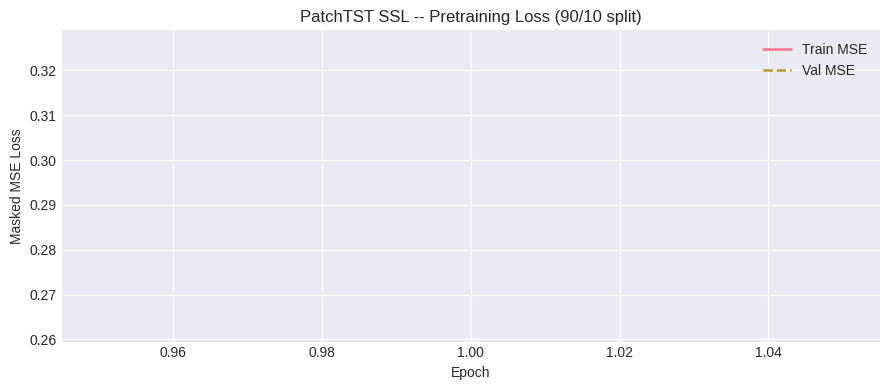

In [7]:
class SSLDataset(Dataset):
    def __init__(self, X): self.X = X
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return torch.from_numpy(self.X[i].astype(np.float32))

class LabeledDataset(Dataset):
    def __init__(self, X, y): self.X = X; self.y = torch.from_numpy(y)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return torch.from_numpy(self.X[i].astype(np.float32)), self.y[i]

def _worker_init_fn(worker_id):
    np.random.seed(CFG.SEED + worker_id)
    random.seed(CFG.SEED + worker_id)


class SSLTrainer:
    """
    SSL pretrainer with:
      - Mixed precision (AMP fp16 forward / fp32 master weights via GradScaler)
      - Checkpoint every CFG.SSL_CKPT_EVERY_N epochs  →  patchtst_ssl_latest.pt
      - Best encoder saved whenever val_loss improves  →  patchtst_ssl_best.pt
      - RESUME: if patchtst_ssl_latest.pt exists, training continues from that epoch
        (useful when Kaggle times out mid-run — just re-run the cell)
    """
    def __init__(self, model: PatchTSTSSL, ckpt_dir: Path):
        self.model       = model.to(CFG.DEVICE)
        self.best_path   = ckpt_dir / 'patchtst_ssl_best.pt'
        self.latest_path = ckpt_dir / 'patchtst_ssl_latest.pt'
        self.emrg_path   = ckpt_dir / 'patchtst_ssl_emergency.pt'
        self.history     = {'train_loss': [], 'val_loss': []}
        self.scaler      = GradScaler(CFG.DEVICE_TYPE, enabled=CFG.USE_AMP)

    def _run_epoch(self, loader, optimizer=None):
        training = optimizer is not None
        self.model.train(training)
        total_loss, total_n = 0.0, 0
        accum = CFG.GRAD_ACCUM
        with (torch.enable_grad() if training else torch.no_grad()):
            if training: optimizer.zero_grad()
            for step, x_batch in enumerate(loader):
                x_batch = x_batch.to(CFG.DEVICE, non_blocking=True)
                if training: x_batch = augment_batch(x_batch)
                with autocast(CFG.DEVICE_TYPE, enabled=CFG.USE_AMP):
                    loss, _, _ = self.model(x_batch, CFG.MASK_RATIO)
                bs       = x_batch.size(0)
                unscaled = loss.item()          # save before dividing by accum
                if training:
                    loss = loss / accum
                    self.scaler.scale(loss).backward()
                    if (step+1) % accum == 0 or (step+1) == len(loader):
                        self.scaler.unscale_(optimizer)
                        nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                        self.scaler.step(optimizer)
                        self.scaler.update()
                        optimizer.zero_grad()
                    if CFG.DEVICE_TYPE == 'cuda' and step % 50 == 0:
                        torch.cuda.empty_cache()
                total_loss += unscaled * bs
                total_n    += bs
        return total_loss / total_n

    def fit(self, X_train, X_val):
        g  = torch.Generator(); g.manual_seed(CFG.SEED)
        kw = dict(num_workers=CFG.NUM_WORKERS, pin_memory=True,
                  persistent_workers=CFG.NUM_WORKERS > 0,
                  worker_init_fn=_worker_init_fn, generator=g)
        train_dl = DataLoader(SSLDataset(X_train), batch_size=CFG.SSL_BATCH, shuffle=True,  **kw)
        val_dl   = DataLoader(SSLDataset(X_val),   batch_size=CFG.SSL_BATCH, shuffle=False, **kw)

        optimizer = AdamW(self.model.parameters(), lr=CFG.SSL_LR, weight_decay=CFG.SSL_WD)
        scheduler = CosineAnnealingLR(optimizer, T_max=CFG.SSL_EPOCHS, eta_min=1e-6)

        best_loss  = float('inf')
        patience   = 0
        start_epoch = 1

        # ── RESUME from latest checkpoint if it exists ──────────────────────
        if self.latest_path.exists():
            print(f'  [RESUME] Found {self.latest_path.name} — loading...')
            ckpt = torch.load(self.latest_path, map_location=CFG.DEVICE)
            self.model.load_state_dict(ckpt['model'])
            optimizer.load_state_dict(ckpt['opt'])
            self.scaler.load_state_dict(ckpt['scaler'])
            self.history  = ckpt['hist']
            start_epoch   = ckpt['epoch'] + 1
            best_loss     = min(self.history['val_loss'])
            # Advance scheduler to correct step
            for _ in range(ckpt['epoch']):
                scheduler.step()
            print(f'  [RESUME] Continuing from epoch {start_epoch} '                  f'(best_loss so far={best_loss:.6f})')
        else:
            print(f'  [FRESH] No checkpoint found — starting from epoch 1.')

        t0 = time.perf_counter()
        print(f'SSL Pretraining mask={CFG.MASK_RATIO} epochs={CFG.SSL_EPOCHS} '              f'patience={CFG.SSL_PATIENCE} AMP={CFG.USE_AMP} fp16_data=True')

        try:
            for epoch in range(start_epoch, CFG.SSL_EPOCHS + 1):
                tr = self._run_epoch(train_dl, optimizer)
                vl = self._run_epoch(val_dl)
                scheduler.step()
                self.history['train_loss'].append(tr)
                self.history['val_loss'].append(vl)

                # Save best encoder
                if vl < best_loss:
                    best_loss = vl; patience = 0
                    enc_state = {k: v for k, v in self.model.encoder.state_dict().items()
                                 if 'total_ops' not in k and 'total_params' not in k}
                    torch.save(enc_state, self.best_path)
                else:
                    patience += 1

                # ── Periodic checkpoint every N epochs (crash/timeout safety) ──
                if epoch % CFG.SSL_CKPT_EVERY_N == 0:
                    torch.save({
                        'epoch':  epoch,
                        'model':  self.model.state_dict(),
                        'opt':    optimizer.state_dict(),
                        'scaler': self.scaler.state_dict(),
                        'hist':   self.history,
                    }, self.latest_path)
                    print(f'  [CKPT] Saved latest checkpoint at epoch {epoch}')

                if epoch % 10 == 0 or epoch == start_epoch:
                    print(f'  Epoch {epoch:3d} train={tr:.6f} val={vl:.6f}'                          f' [best={best_loss:.6f} patience={patience}/{CFG.SSL_PATIENCE}]')

                if epoch >= CFG.SSL_MIN_EPOCHS and patience >= CFG.SSL_PATIENCE:
                    print(f'  Early stop at epoch {epoch}'); break

        except (KeyboardInterrupt, RuntimeError) as exc:
            print(f'  Interrupted: {exc}')
            torch.save({'model': self.model.state_dict(), 'hist': self.history}, self.emrg_path)
            print(f'  Emergency checkpoint saved → {self.emrg_path}')
            raise

        self.train_wall = time.perf_counter() - t0
        print(f'  Done. Wall={self.train_wall:.1f}s Best val_loss={best_loss:.6f}')
        return self


ssl_trainer = SSLTrainer(ssl_model, CFG.CKPT_DIR)
ssl_trainer.fit(X_train, X_val)

fig, ax = plt.subplots(figsize=(9, 4))
hist = ssl_trainer.history
ep = range(1, len(hist['train_loss']) + 1)
ax.plot(ep, hist['train_loss'], label='Train MSE', lw=1.8)
ax.plot(ep, hist['val_loss'],   label='Val MSE',   lw=1.8, ls='--')
ax.set_xlabel('Epoch'); ax.set_ylabel('Masked MSE Loss')
ax.set_title('PatchTST SSL -- Pretraining Loss (90/10 split)')
ax.legend(); plt.tight_layout()
fig.savefig(CFG.PLOT_DIR / 'ssl_pretraining_curve.png', dpi=150)
plt.show(); plt.close('all')


## 7 Downstream evaluation

In [8]:
def load_frozen_encoder() -> PatchTSTEncoder:
    if not (CFG.CKPT_DIR / 'patchtst_ssl_best.pt').exists():
        raise FileNotFoundError('Best SSL checkpoint not found. Ensure SSL training completed.')
    enc = PatchTSTEncoder(c_in=CFG.N_CHANNELS, num_patch=CFG.NUM_PATCH, patch_len=CFG.PATCH_LEN,
                          n_layers=CFG.N_LAYERS, d_model=CFG.D_MODEL, n_heads=CFG.N_HEADS,
                          d_ff=CFG.D_FF, norm=CFG.NORM, attn_dropout=CFG.ATTN_DROPOUT,
                          dropout=CFG.DROPOUT, act='gelu', res_attention=CFG.RES_ATTENTION,
                          pre_norm=CFG.PRE_NORM, pe='zeros', learn_pe=True,
                          shared_embedding=CFG.SHARED_EMBEDDING).to(CFG.DEVICE)
    state = torch.load(CFG.CKPT_DIR / 'patchtst_ssl_best.pt', map_location=CFG.DEVICE)
    state = {k: v for k, v in state.items()
             if 'total_ops' not in k and 'total_params' not in k}
    enc.load_state_dict(state)
    enc.eval()
    for p in enc.parameters(): p.requires_grad_(False)
    return enc


@torch.no_grad()
def extract_features(encoder: PatchTSTEncoder, X: np.ndarray, batch_size: int = 256) -> np.ndarray:
    """FIX Bug4: empty_cache every 20 batches. FIX Dev1: mean pool over all patches."""
    encoder.eval(); feats = []
    for i in range(0, len(X), batch_size):
        xb = torch.from_numpy(X[i:i+batch_size].astype(np.float32)).to(CFG.DEVICE)
        xb_t = xb.transpose(1, 2)
        with autocast(CFG.DEVICE_TYPE, enabled=CFG.USE_AMP):
            xb_p, _ = create_patch(xb_t, CFG.PATCH_LEN, CFG.PATCH_STRIDE)
            enc_out  = encoder(xb_p)
        feat = enc_out.mean(dim=2).flatten(1).float().cpu().numpy()
        feats.append(feat)
        del xb, xb_t, xb_p, enc_out, feat
        if CFG.DEVICE_TYPE == 'cuda' and (i // batch_size) % 20 == 0:
            torch.cuda.empty_cache()
    return np.vstack(feats)


frozen_enc = load_frozen_encoder()
print('Extracting frozen features (mean-pool, 90/10 split)...')
t0 = time.perf_counter()
F_train = extract_features(frozen_enc, X_train)
F_val   = extract_features(frozen_enc, X_val)
F_test  = extract_features(frozen_enc, X_test)
print(f'Feature dim : {F_train.shape[1]:,} | Time : {time.perf_counter()-t0:.1f}s')

feat_scaler  = StandardScaler()
F_train_sc   = feat_scaler.fit_transform(F_train)
F_val_sc     = feat_scaler.transform(F_val)
F_test_sc    = feat_scaler.transform(F_test)

# ── NaN guard (safe with undertrained encoder / smoke-test mode) ────────────
# With epoch=2 the encoder is near-random and can produce NaN/Inf embeddings.
# np.nan_to_num is a no-op once properly trained (100-150 epochs).
F_train_sc = np.nan_to_num(F_train_sc, nan=0.0, posinf=0.0, neginf=0.0)
F_val_sc   = np.nan_to_num(F_val_sc,   nan=0.0, posinf=0.0, neginf=0.0)
F_test_sc  = np.nan_to_num(F_test_sc,  nan=0.0, posinf=0.0, neginf=0.0)
_nan_n = np.isnan(F_train_sc).sum() + np.isnan(F_test_sc).sum()
if _nan_n > 0:
    print(f'[NaN guard] Replaced {_nan_n} NaN/Inf values — expected in smoke-test mode.')
else:
    print('[NaN guard] No NaN/Inf detected — encoder output is clean.')

# -- Linear Probe --------------------------------------------------------------
print('-- Linear Probe --')
t0 = time.perf_counter()
lr_clf = LogisticRegression(max_iter=2000, C=1.0, solver='lbfgs',
                             multi_class='multinomial', n_jobs=-1, random_state=CFG.SEED)
lr_clf.fit(F_train_sc, y_train)
lp_train_time = time.perf_counter() - t0
t0 = time.perf_counter()
lp_pred = lr_clf.predict(F_test_sc)
lp_test_time = time.perf_counter() - t0
lp_acc = accuracy_score(y_test, lp_pred)
print(f'  Linear Probe Accuracy: {lp_acc:.4f} '
      f'(train={lp_train_time:.1f}s infer={lp_test_time*1000:.1f}ms)')

# -- Shallow heads -------------------------------------------------------------
shallow_results = {}
heads = {
    'MLP (frozen)': MLPClassifier(hidden_layer_sizes=(256, 128), activation='relu',
                                   max_iter=200, random_state=CFG.SEED, early_stopping=True),
    'SVM (frozen)': SVC(C=1.0, kernel='rbf', probability=True,
                         random_state=CFG.SEED, decision_function_shape='ovr'),
    'DT (frozen)':  DecisionTreeClassifier(max_depth=15, random_state=CFG.SEED),
    'RF (frozen)':  RandomForestClassifier(n_estimators=200, max_depth=20,
                                            n_jobs=-1, random_state=CFG.SEED),
}
for name, clf in heads.items():
    t0 = time.perf_counter()
    clf.fit(F_train_sc, y_train)
    tr_t = time.perf_counter() - t0
    t0 = time.perf_counter()
    pred = clf.predict(F_test_sc)
    te_t = time.perf_counter() - t0
    acc  = accuracy_score(y_test, pred)
    print(f'  {name:20s} acc={acc:.4f} train={tr_t:.1f}s infer={te_t*1000:.1f}ms')
    shallow_results[name] = {'clf': clf, 'pred': pred, 'acc': acc,
                              'train_time': tr_t, 'test_time': te_t}


Extracting frozen features (mean-pool, 90/10 split)...
Feature dim : 6,144 | Time : 38.7s
[NaN guard] No NaN/Inf detected — encoder output is clean.
-- Linear Probe --


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


  Linear Probe Accuracy: 0.1524 (train=1627.7s infer=126.4ms)
  MLP (frozen)         acc=0.2601 train=276.2s infer=82.1ms
  SVM (frozen)         acc=0.1441 train=18476.5s infer=916828.6ms
  DT (frozen)          acc=0.1055 train=551.9s infer=12.3ms
  RF (frozen)          acc=0.1789 train=361.6s infer=148.7ms


## 8 Full fine-tune

In [9]:
class DownstreamTrainer:
    """
    Fine-tune trainer with:
      - Mixed precision AMP (fp16 forward / fp32 master weights)
      - Periodic checkpoint every CFG.FT_CKPT_EVERY_N epochs  → patchtst_ft_latest.pt
      - Best model saved on val_loss improvement               → patchtst_ft_best.pt
      - RESUME: if patchtst_ft_latest.pt exists, continues from that epoch
    """
    def __init__(self, model, ckpt_path: Path):
        self.model       = model.to(CFG.DEVICE)
        self.best_path   = ckpt_path
        self.latest_path = ckpt_path.parent / 'patchtst_ft_latest.pt'
        self.history     = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
        self.scaler      = GradScaler(CFG.DEVICE_TYPE, enabled=CFG.USE_AMP)

    def _run_epoch(self, loader, optimizer=None, criterion=None):
        training = optimizer is not None
        self.model.train(training)
        total_loss, correct, total = 0.0, 0, 0
        with (torch.enable_grad() if training else torch.no_grad()):
            for xb, yb in loader:
                xb, yb = xb.to(CFG.DEVICE, non_blocking=True), yb.to(CFG.DEVICE)
                with autocast(CFG.DEVICE_TYPE, enabled=CFG.USE_AMP):
                    logits = self.model(xb)
                    if criterion is not None:
                        loss = criterion(logits, yb)
                if training and criterion is not None:
                    optimizer.zero_grad()
                    self.scaler.scale(loss).backward()
                    self.scaler.unscale_(optimizer)
                    nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                    self.scaler.step(optimizer)
                    self.scaler.update()
                if criterion is not None:
                    total_loss += loss.item() * len(yb)
                correct += (logits.argmax(1) == yb).sum().item()
                total   += len(yb)
        return (total_loss / total if total > 0 else 0.), correct / total

    def fit(self, X_tr, y_tr, X_vl, y_vl):
        g  = torch.Generator(); g.manual_seed(CFG.SEED)
        kw = dict(num_workers=CFG.NUM_WORKERS, pin_memory=True,
                  persistent_workers=CFG.NUM_WORKERS > 0,
                  worker_init_fn=_worker_init_fn, generator=g)
        tr_dl = DataLoader(LabeledDataset(X_tr, y_tr), batch_size=CFG.FT_BATCH, shuffle=True,  **kw)
        vl_dl = DataLoader(LabeledDataset(X_vl, y_vl), batch_size=CFG.FT_BATCH, shuffle=False, **kw)

        optimizer = AdamW(self.model.parameters(), lr=CFG.FT_LR, weight_decay=CFG.FT_WD)
        criterion = nn.CrossEntropyLoss()
        scheduler = CosineAnnealingLR(optimizer, T_max=CFG.FT_EPOCHS, eta_min=1e-6)

        best_vl     = float('inf')
        patience    = 0
        start_epoch = 1

        # ── RESUME from latest FT checkpoint if it exists ───────────────────
        if self.latest_path.exists():
            print(f'  [RESUME] Found {self.latest_path.name} — loading...')
            ckpt = torch.load(self.latest_path, map_location=CFG.DEVICE)
            self.model.load_state_dict(ckpt['model'])
            optimizer.load_state_dict(ckpt['opt'])
            self.scaler.load_state_dict(ckpt['scaler'])
            self.history  = ckpt['hist']
            start_epoch   = ckpt['epoch'] + 1
            best_vl       = min(self.history['val_loss'])
            for _ in range(ckpt['epoch']):
                scheduler.step()
            print(f'  [RESUME] Continuing fine-tune from epoch {start_epoch} '                  f'(best_val_loss={best_vl:.6f})')
        else:
            print(f'  [FRESH] No FT checkpoint — starting fine-tune from epoch 1.')

        t0 = time.perf_counter()
        print('Fine-tuning PatchTST end-to-end (AMP fp16)...')

        try:
            for epoch in range(start_epoch, CFG.FT_EPOCHS + 1):
                tr_l, tr_a = self._run_epoch(tr_dl, optimizer, criterion)
                vl_l, vl_a = self._run_epoch(vl_dl, criterion=criterion)
                scheduler.step()
                self.history['train_loss'].append(tr_l)
                self.history['val_loss'].append(vl_l)
                self.history['train_acc'].append(tr_a)
                self.history['val_acc'].append(vl_a)

                # Save best model
                if vl_l < best_vl:
                    best_vl, patience = vl_l, 0
                    torch.save(self.model.state_dict(), self.best_path)
                else:
                    patience += 1

                # ── Periodic checkpoint every N epochs ───────────────────────
                if epoch % CFG.FT_CKPT_EVERY_N == 0:
                    torch.save({
                        'epoch':  epoch,
                        'model':  self.model.state_dict(),
                        'opt':    optimizer.state_dict(),
                        'scaler': self.scaler.state_dict(),
                        'hist':   self.history,
                    }, self.latest_path)
                    print(f'  [CKPT] FT checkpoint saved at epoch {epoch}')

                if epoch % 10 == 0 or epoch == start_epoch:
                    print(f'  Epoch {epoch:3d} tr={tr_l:.4f}/{tr_a:.4f} '                          f'vl={vl_l:.4f}/{vl_a:.4f} '                          f'[best={best_vl:.4f} pat={patience}/{CFG.FT_PATIENCE}]')

                if epoch >= CFG.FT_MIN_EPOCHS and patience >= CFG.FT_PATIENCE:
                    print(f'  Early stop at epoch {epoch}'); break

        except (KeyboardInterrupt, RuntimeError) as exc:
            print(f'  Fine-tune interrupted: {exc}')
            torch.save({
                'epoch':  epoch,
                'model':  self.model.state_dict(),
                'opt':    optimizer.state_dict(),
                'scaler': self.scaler.state_dict(),
                'hist':   self.history,
            }, self.latest_path)
            print(f'  Emergency FT checkpoint saved → {self.latest_path}')
            raise

        self.train_wall = time.perf_counter() - t0
        print(f'  Done. Wall={self.train_wall:.1f}s')
        return self


ft_enc = load_frozen_encoder()
for p in ft_enc.parameters(): p.requires_grad_(True)
ft_model = PatchTSTClassifier(encoder=ft_enc, n_classes=CFG.N_CLASSES,
                               patch_len=CFG.PATCH_LEN, stride=CFG.PATCH_STRIDE,
                               freeze_encoder=False).to(CFG.DEVICE)
ft_trainer = DownstreamTrainer(ft_model, CFG.CKPT_DIR / 'patchtst_ft_best.pt')
ft_trainer.fit(X_train, y_train, X_val, y_val)

@torch.no_grad()
def predict_classifier(model, X, batch_size=256):
    model.eval(); preds, probas = [], []
    for i in range(0, len(X), batch_size):
        xb = torch.from_numpy(X[i:i+batch_size].astype(np.float32)).to(CFG.DEVICE)
        with autocast(CFG.DEVICE_TYPE, enabled=CFG.USE_AMP):
            logits = model(xb)
        preds.append(logits.argmax(1).cpu().numpy())
        probas.append(F.softmax(logits.float(), dim=-1).cpu().numpy())
        del xb, logits
    return np.concatenate(preds), np.concatenate(probas)

ft_state = torch.load(CFG.CKPT_DIR / 'patchtst_ft_best.pt', map_location=CFG.DEVICE)
ft_model.load_state_dict(ft_state)
t0 = time.perf_counter()
ft_pred, ft_proba = predict_classifier(ft_model, X_test)
ft_test_time = time.perf_counter() - t0
ft_acc = accuracy_score(y_test, ft_pred)
print(f'Full Fine-Tune Accuracy : {ft_acc:.4f}')
print(f'Linear Probe Accuracy   : {lp_acc:.4f}')
print(f'Fine-tune gain over LP  : {ft_acc-lp_acc:+.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ep = range(1, len(ft_trainer.history['train_loss']) + 1)
axes[0].plot(ep, ft_trainer.history['train_loss'], label='Train', lw=1.8)
axes[0].plot(ep, ft_trainer.history['val_loss'],   label='Val',   lw=1.8, ls='--')
axes[0].set_title('Fine-Tune: Loss'); axes[0].legend()
axes[1].plot(ep, ft_trainer.history['train_acc'], label='Train', lw=1.8)
axes[1].plot(ep, ft_trainer.history['val_acc'],   label='Val',   lw=1.8, ls='--')
axes[1].axhline(lp_acc, color='red', ls=':', label=f'Linear Probe ({lp_acc:.3f})')
axes[1].set_title('Fine-Tune: Accuracy'); axes[1].legend()
plt.tight_layout()
fig.savefig(CFG.PLOT_DIR / 'downstream_learning_curves.png', dpi=150)
plt.show(); plt.close('all')


  [FRESH] No FT checkpoint — starting fine-tune from epoch 1.
Fine-tuning PatchTST end-to-end (AMP fp16)...
  Epoch   1 tr=nan/0.4240 vl=nan/0.0596 [best=inf pat=1/20]
  [CKPT] FT checkpoint saved at epoch 5
  [CKPT] FT checkpoint saved at epoch 10
  Epoch  10 tr=nan/0.0597 vl=nan/0.0596 [best=inf pat=10/20]
  [CKPT] FT checkpoint saved at epoch 15
  [CKPT] FT checkpoint saved at epoch 20
  Epoch  20 tr=nan/0.0597 vl=nan/0.0596 [best=inf pat=20/20]
  [CKPT] FT checkpoint saved at epoch 25
  [CKPT] FT checkpoint saved at epoch 30
  Epoch  30 tr=nan/0.0597 vl=nan/0.0596 [best=inf pat=30/20]
  [CKPT] FT checkpoint saved at epoch 35
  [CKPT] FT checkpoint saved at epoch 40
  Epoch  40 tr=nan/0.0597 vl=nan/0.0596 [best=inf pat=40/20]
  [CKPT] FT checkpoint saved at epoch 45
  [CKPT] FT checkpoint saved at epoch 50
  Epoch  50 tr=nan/0.0597 vl=nan/0.0596 [best=inf pat=50/20]
  [CKPT] FT checkpoint saved at epoch 55
  [CKPT] FT checkpoint saved at epoch 60
  Epoch  60 tr=nan/0.0597 vl=nan/0.0

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/ckpts_patchtst_ssl/patchtst_ft_best.pt'

## §9 Embedding analysis

In [ ]:
rng = np.random.default_rng(CFG.SEED)
idx = rng.choice(len(F_test), size=min(CFG.VIZ_SAMPLES, len(F_test)), replace=False)
F_viz, y_viz = F_test_sc[idx], y_test[idx]

sil = silhouette_score(F_test_sc, y_test, metric='euclidean',
                        sample_size=5000, random_state=CFG.SEED)
print(f'Silhouette Score (frozen, 90/10): {sil:.4f}')

pca    = PCA(n_components=2, random_state=CFG.SEED)
F_pca  = pca.fit_transform(F_viz)
print(f'PCA explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%')

tsne   = TSNE(n_components=2, perplexity=40, n_iter=1000, random_state=CFG.SEED, n_jobs=-1)
F_tsne = tsne.fit_transform(F_viz)

F_umap = None
if HAS_UMAP:
    reducer = umap_module.UMAP(n_components=2, n_neighbors=30, min_dist=0.1, random_state=CFG.SEED)
    F_umap  = reducer.fit_transform(F_viz)

n_plots = 3 if F_umap is not None else 2
fig, axes = plt.subplots(1, n_plots, figsize=(7*n_plots, 6))
palette   = sns.color_palette('husl', CFG.N_CLASSES)

def _scatter(ax, Z, title):
    for ci in range(CFG.N_CLASSES):
        m = y_viz == ci
        ax.scatter(Z[m, 0], Z[m, 1], c=[palette[ci]], s=6, alpha=0.6, label=CLASS_NAMES[ci])
    ax.set_title(f'{title}\n(Sil={sil:.3f})', fontsize=13)
    ax.set_xticks([]); ax.set_yticks([])

_scatter(axes[0], F_pca,  'PCA')
_scatter(axes[1], F_tsne, 't-SNE')
if F_umap is not None: _scatter(axes[2], F_umap, 'UMAP')
handles, labels_ = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_, bbox_to_anchor=(1.01, 0.5), loc='center left',
           markerscale=2, fontsize=8)
plt.suptitle('PatchTST SSL -- Frozen Embeddings (Test Set, 90/10)', fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(CFG.PLOT_DIR / 'embedding_analysis.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close('all')


## §10 Metrics & results log

In [ ]:
def compute_metrics(name, y_true, y_pred, y_proba=None, train_time=0., test_time=0.):
    acc    = accuracy_score(y_true, y_pred)
    per_cl = {CLASS_NAMES[i]: accuracy_score(y_true[y_true==i], y_pred[y_true==i])
              for i in range(CFG.N_CLASSES) if (y_true==i).any()}
    prec   = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec    = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1     = f1_score(y_true, y_pred, average='macro', zero_division=0)
    roc_auc = None
    if y_proba is not None and y_proba.ndim == 2:
        try:
            roc_auc = roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro')
        except Exception:
            pass
    return dict(name=name, accuracy=acc, per_class=per_cl,
                precision=prec, recall=rec, f1=f1, roc_auc=roc_auc,
                train_time=train_time, test_time=test_time)

def get_proba(clf, X):
    try: return clf.predict_proba(X)
    except: return None

all_metrics = []
lp_proba    = lr_clf.predict_proba(F_test_sc)
all_metrics.append(compute_metrics('Linear Probe', y_test, lp_pred, lp_proba,
                                   lp_train_time, lp_test_time))
for name, res in shallow_results.items():
    all_metrics.append(compute_metrics(name, y_test, res['pred'],
                                       get_proba(res['clf'], F_test_sc),
                                       res['train_time'], res['test_time']))
all_metrics.append(compute_metrics('Full Fine-Tune', y_test, ft_pred, ft_proba,
                                   ft_trainer.train_wall, ft_test_time))

rows = [{'Method': m['name'], 'Accuracy': f"{m['accuracy']:.4f}",
         'Precision': f"{m['precision']:.4f}", 'Recall': f"{m['recall']:.4f}",
         'F1-Macro': f"{m['f1']:.4f}",
         'ROC-AUC': f"{m['roc_auc']:.4f}" if m['roc_auc'] else 'N/A',
         'Train(s)': f"{m['train_time']:.1f}", 'Infer(ms)': f"{m['test_time']*1000:.1f}"}
        for m in all_metrics]
df_summary = pd.DataFrame(rows)
print('\n-- Method Comparison (90/10 split) --')
print(df_summary.to_string(index=False))
df_summary.to_csv(CFG.RESULTS_DIR / 'method_comparison_90_10.csv', index=False)

# -- Confusion matrices -------------------------------------------------------
key_methods = [('Linear Probe', lp_pred), ('Full Fine-Tune', ft_pred),
               ('RF (frozen)', shallow_results['RF (frozen)']['pred'])]
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
for ax, (name, pred) in zip(axes, key_methods):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    ax.set_title(f'{name}\nAcc={accuracy_score(y_test, pred):.3f}')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.suptitle('Confusion Matrices -- PatchTST SSL (90/10)', fontsize=13)
plt.tight_layout()
fig.savefig(CFG.PLOT_DIR / 'confusion_matrices.png', dpi=150)
plt.show(); plt.close('all')

# -- k-NN ---------------------------------------------------------------------
knn_results = {}
print('-- k-NN in Embedding Space --')
for k in CFG.KNN_KS:
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1, metric='euclidean')
    knn.fit(F_train_sc, y_train)
    acc_k = accuracy_score(y_test, knn.predict(F_test_sc))
    knn_results[k] = acc_k
    print(f'  k={k:2d} acc={acc_k:.4f}')

# -- Label-efficiency curve ---------------------------------------------------
print('-- Label-Efficiency Curve --')
leff_accs = []
F_tv = np.concatenate([F_train_sc, F_val_sc])
y_tv = np.concatenate([y_train, y_val])
for frac in CFG.LABEL_FRACS:
    n_sub = max(CFG.N_CLASSES, int(frac * len(F_tv)))
    try:
        sss = StratifiedShuffleSplit(n_splits=1, train_size=n_sub, random_state=CFG.SEED)
        sub_idx, _ = next(sss.split(F_tv, y_tv))
    except Exception:
        sub_idx = np.random.choice(len(F_tv), n_sub, replace=False)
    clf_sub = LogisticRegression(max_iter=500, C=1.0, solver='lbfgs',
                                 multi_class='multinomial', n_jobs=-1, random_state=CFG.SEED)
    clf_sub.fit(F_tv[sub_idx], y_tv[sub_idx])
    acc_sub = accuracy_score(y_test, clf_sub.predict(F_test_sc))
    leff_accs.append(acc_sub)
    print(f'  {frac*100:4.0f}% ({n_sub} samples) -> acc={acc_sub:.4f}')

# -- Final JSON ---------------------------------------------------------------
final_results = {
    'model': 'PatchTST_SSL_pipeline_90_10',
    'dataset': 'NinaPro_DB7_ExB_G13-29',
    'split': '90/10 stratified',
    'win_ms': CFG.WIN_MS, 'step_ms': CFG.STEP_MS,
    'n_channels': CFG.N_CHANNELS, 'patch_len': CFG.PATCH_LEN,
    'num_patch': CFG.NUM_PATCH, 'mask_ratio': CFG.MASK_RATIO,
    'shared_embedding': CFG.SHARED_EMBEDDING,
    'ssl_epochs_run': len(ssl_trainer.history['train_loss']),
    'ssl_best_val_loss': float(min(ssl_trainer.history['val_loss'])),
    'ssl_wall_s': float(ssl_trainer.train_wall),
    'ft_wall_s': float(ft_trainer.train_wall),
    'silhouette': float(sil),
    'knn': {f'k={k}': float(v) for k, v in knn_results.items()},
    'label_efficiency': {f'{f*100:.0f}%': float(a) for f, a in zip(CFG.LABEL_FRACS, leff_accs)},
    'methods': [{'name': m['name'], 'accuracy': float(m['accuracy']),
                  'precision_macro': float(m['precision']),
                  'recall_macro': float(m['recall']),
                  'f1_macro': float(m['f1']),
                  'roc_auc_macro': float(m['roc_auc']) if m['roc_auc'] else None,
                  'train_time_s': float(m['train_time']),
                  'test_time_ms': float(m['test_time']*1000)}
                 for m in all_metrics],
}
with open(CFG.RESULTS_DIR / 'patchtst_results_90_10.json', 'w') as f:
    json.dump(final_results, f, indent=2)
print(f'\nResults saved -> {CFG.RESULTS_DIR}/patchtst_results_90_10.json')

print('\n== FINAL SUMMARY (90/10) ==')
print(f'  Silhouette (frozen) : {sil:.4f}')
print(f'  k-NN : {" | ".join(f"k={k}->{v:.4f}" for k,v in knn_results.items())}')
print(f'  Linear Probe Accuracy : {lp_acc:.4f}')
print(f'  Full Fine-Tune Accuracy : {ft_acc:.4f}')
print(f'  Fine-tune gain over LP  : {ft_acc-lp_acc:+.4f}')
for m in all_metrics:
    pc = m['per_class']
    worst3 = sorted(pc, key=lambda k: pc[k])[:3]
    best3  = sorted(pc, key=lambda k: pc[k], reverse=True)[:3]
    print(f"  {m['name']:20s} acc={m['accuracy']:.4f} f1={m['f1']:.4f}"
          + (f" auc={m['roc_auc']:.4f}" if m['roc_auc'] else ''))
    print(f"    worst 3: { {g: f'{pc[g]:.3f}' for g in worst3} }")
    print(f"    best 3 : { {g: f'{pc[g]:.3f}' for g in best3} }")


## 🔧 Added: Global Leakage-Safe 90/10 Split (Non Subject-wise)

In [ ]:

def global_time_split(X, y, test_frac=CFG.TEST_FRAC, gap=128):
    N = len(X)
    split = int(N * (1 - test_frac))

    train_end = split - gap
    test_start = split + gap

    X_train = X[:train_end]
    y_train = y[:train_end]

    X_test = X[test_start:]
    y_test = y[test_start:]

    print(f"[GLOBAL SPLIT] Train: {len(X_train)}, Test: {len(X_test)}")
    return X_train, X_test, y_train, y_test


In [ ]:

def load_all_subjects(subject_ids):
    all_emg, all_labels = [], []

    for sid in subject_ids:
        ckpt = subject_loader._ckpt_path(sid)
        if not ckpt.exists():
            continue
        d = np.load(ckpt, allow_pickle=True)
        all_emg.append(d['emg'])
        all_labels.append(d['labels'])

    X = np.concatenate(all_emg, axis=0)
    y = np.concatenate(all_labels, axis=0)

    print(f"[LOAD] Total samples: {len(X)}")
    return X, y


In [ ]:

def prepare_global_data(subject_ids):
    X, y = load_all_subjects(subject_ids)

    X_tr, X_te, y_tr, y_te = global_time_split(X, y)

    X_tr_w, y_tr_w = build_windows(X_tr, y_tr)
    X_te_w, y_te_w = build_windows(X_te, y_te)

    scaler = StandardScaler()
    X_tr_flat = X_tr_w.reshape(len(X_tr_w), -1)
    X_te_flat = X_te_w.reshape(len(X_te_w), -1)

    scaler.fit(X_tr_flat)

    X_tr_w = scaler.transform(X_tr_flat).reshape(X_tr_w.shape)
    X_te_w = scaler.transform(X_te_flat).reshape(X_te_w.shape)

    return X_tr_w, X_te_w, y_tr_w, y_te_w


In [ ]:

# Example usage:
# subject_ids = list(range(1, CFG.N_SUBJECTS+1))
# X_train, X_test, y_train, y_test = prepare_global_data(subject_ids)
